In [22]:
import pandas as pd

In [23]:
from Descriptive import Descriptive

In [24]:
obj=Descriptive()

In [25]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [26]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [27]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [28]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2024-05-02,1454.460329,1459.721831,1446.679164,1449.075317
2024-05-03,1453.472210,1457.375095,1399.275803,1416.913086
2024-05-06,1418.395221,1422.841601,1401.103743,1402.610596
2024-05-07,1399.102736,1403.820863,1375.413437,1384.775513
2024-05-08,1380.847991,1415.875536,1380.847991,1401.647217
...,...,...,...,...
2025-10-01,1360.708629,1372.255218,1356.428371,1362.400757
2025-10-03,1356.926092,1365.287457,1350.655159,1357.125244


In [29]:
column="Close"

In [30]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (358, 1)


In [31]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

286
X_train length: (286, 1)
X_test length: (72, 1)
y_train length: (286, 1)
y_test length: (72, 1)


In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [48]:
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA 
for td in trends:
        #print(td)
        #trendslist.append(td)
        model = ARIMA(X_train, order=(0,0,10),trend=td,)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        from stockFunctions1 import rmsemape
        print("Trend={}".format(td))
        from sklearn.metrics import r2_score
        mse = mean_squared_error(y_test, y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmsemape(y_test,y_pred)
        print("************")

Trend=n
RMSE-Testset: 0.5630260925519306
MAPE-Testset: 0.9442295595501184
************
Trend=t
RMSE-Testset: 0.17695104903491274
MAPE-Testset: 0.2980730102199154
************
Trend=c
RMSE-Testset: 0.13975183246748396
MAPE-Testset: 0.14080698027004868
************
Trend=ct
RMSE-Testset: 0.3634376333988578
MAPE-Testset: 0.5974027234923942
************


In [49]:
len(y_pred)

72

In [51]:
td='c'
model = ARIMA(X_train, order=(0,0,30),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
from stockFunctions1 import rmsemape
print("Trend={}".format(td))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmsemape(y_test,y_pred)
print("************")

Trend=c
RMSE-Testset: 0.06158313589619807
MAPE-Testset: 0.07393287356380385
************


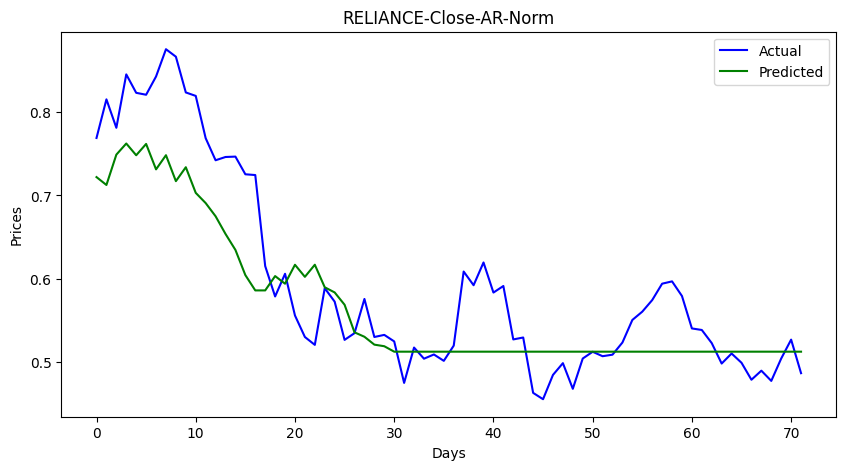

In [52]:
from stockFunctions1 import graph
graph(y_test,y_pred,"Actual","Predicted","RELIANCE-Close-AR-Norm","Days","Prices")

In [53]:
len(data1)

358

In [55]:
from stockFunctions1 import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [56]:
from stockFunctions1 import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

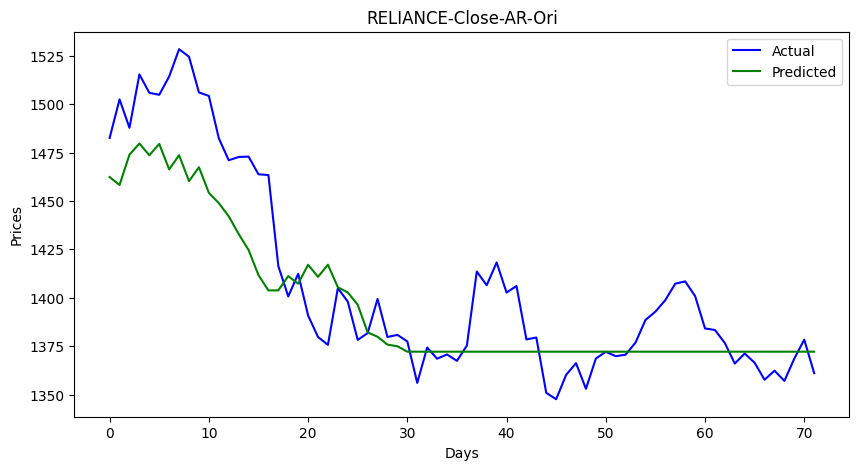

In [57]:
from stockFunctions1 import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","RELIANCE-Close-AR-Ori","Days","Prices")

In [59]:
from stockFunctions1 import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 26.472907711397898
MAPE-Testset: 0.014159223849794792


In [60]:
forecast=model_fit.predict(len(data1), len(data1))

In [62]:
from stockFunctions1 import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [63]:
forecast_stock_price_test_oriF

,Closefore
0,1372.207497


In [65]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)